Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.
***

# Введение

В этом домашнем задании мы пройдемся по трем основным типам задач машинного обучения, которые обсуждали на паре:
* **регрессия** (предсказание числа);
* **классификация** (предсказание класса);
* **кластеризация** (поиск скрытых структур в данных).

Подробно про типы задач МО вообще и модели почитать [тут](https://scikit-learn.org/stable/user_guide.html?spm=a2ty_o01.29997173.0.0.3ef45171As9d36).

_Ноутбук представляет из себя работу над **тремя видами задач** и **итоговый отчет**_

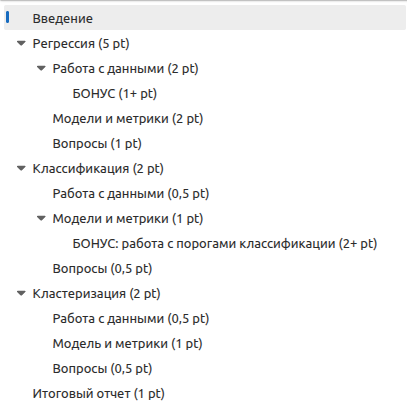

Для каждой задачи нужно поработать с данными, обучить модели и поработать с метриками, ответить на вопросы. Все задания будут подробно сформулированы в соответствующих пунктах.

> **Наша цель — не научиться хорошо предсказывать, а понять, как данные влияют на предсказание и как с ними работать!**

In [1]:
!pip install tqdm  



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from typing import List, Union, Dict
from tqdm.auto import tqdm
from IPython.display import clear_output

c:\Users\pochi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Регрессия (5 pt)

В задачах регрессии цель — предсказать **непрерывную числовую переменную** (например, цену).  

В этом задании мы будем использовать для предсказания и сравнения две модели: `SGDRegressor` (линейная регрессия, обучающаяся через градиентный спуск) и `RandomForestRegressor`. Обе они легко импортятся, мы будем их просто использовать, не будем погружаться в детали. Однако если вы хотите **поэксперементировать с параметрами**, то вы можете это сделать, но не забудьте **сделать то, что прошу в задании**.

Также в этом задании мы поработаем с _двумя типами кодирования категориальных признаков_ и с _тремя метриками_.

## Работа с данными (2 pt)

Для задачи регрессии возьмем датасет `diamonds`, с которым вы уже знакомы. 

In [3]:
diamonds = sns.load_dataset('diamonds')
diamonds.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


In [4]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


Для начала разделим наши данные на обучающую и тестовую выборки с помощью `train_test_split`: будем использовать **один сид** для сравнения и воспроизводимости (не меняйте его).

In [5]:
X = diamonds.drop('price', axis=1) # признаки
y = diamonds['price'] # таргет 

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train_raw.shape, X_test_raw.shape)
print(type(X_test_raw))
print(y_train.head(10))

(43152, 9) (10788, 9)
<class 'pandas.DataFrame'>
26546    16231
9159      4540
14131     5729
15757     6300
24632    12968
49828     2167
38682     1041
44604     1607
11459     5008
2495      3197
Name: price, dtype: int64


Теперь будем работать только с обучающим набором, как будто про тест мы ничего не знаем.

**ВАЖНО!**  
Все трансформы и **статистики мы считаем только по трэйну, а к тесту их применяем с теми же параметрами**. Нужно понимать, что про тест мы ничего не знаем, а значит для нас это неизвестный набор данных по подобию трэйна, то есть мы на нем никакие статистики не посчитаем!

Давайте посмотрим, как **распределена целевая переменная**.

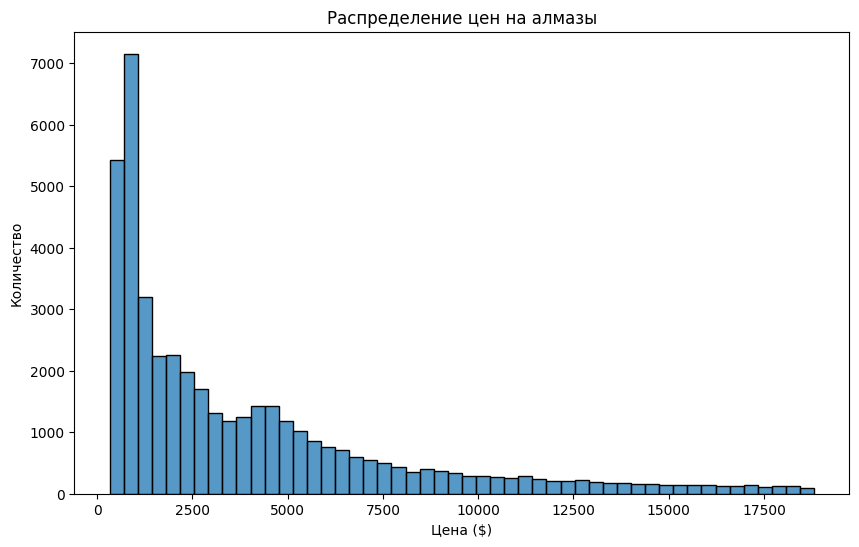

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=y_train, bins=50)
plt.title('Распределение цен на алмазы')
plt.xlabel('Цена ($)')
plt.ylabel('Количество')
plt.show()

Отдельно изучим **категориальные данные**

In [7]:
categorical_cols = ['cut', 'color', 'clarity']

for col in categorical_cols:
    print(X_train_raw[col].value_counts(), "\n")

cut
Ideal        17259
Premium      11016
Very Good     9700
Good          3902
Fair          1275
Name: count, dtype: int64 

color
G    9015
E    7863
F    7644
H    6707
D    5413
I    4274
J    2236
Name: count, dtype: int64 

clarity
SI1     10520
VS2      9793
SI2      7306
VS1      6530
VVS2     4044
VVS1     2944
IF       1430
I1        585
Name: count, dtype: int64 



Какие признаки являются **ординальными** (имеют порядок), а какие **номинальными** (без порядка)?  

**ОТВЕТ:** огранка и чистота ординальные, цвет - номинальный.

Почистите обучающие данные, если это требуется. Если нет, то напишите, почему вы решили этого не делать.  
(Вы можете сделать то же самое, что делали в третьей домашке)

In [8]:
# print("дубликаты\n", X_train_raw.duplicated().sum())

# X_train_raw = X_train_raw.drop_duplicates()

# print("пропуски")

# X_train_raw.isna().sum()

In [9]:
# X_train_raw = X_train_raw[(X_train_raw['x'] != 0) & 
#                           (X_train_raw['y'] != 0) & 
#                           (X_train_raw['z'] != 0)]

# (X_train_raw[['x','y','z']] == 0).sum()

# (X_train_raw[['x','y','z']] <= 0).sum()
# (X_train_raw['carat'] <= 0).sum()
# # количество нулей и отрицательных
# (y_train <= 0).sum()



сначала я удалила дубликаты, удалила строки, где у размеров были нулевые значения. пропусков в датасете нет. потом при обучении модели у меня вылезли ошибки, потому что я удаляла только в x_train. то есть надо было чистить до разделения. но тк там есть дубликаты и отрицательные размеры, можно и не чистить. размеры мы для обучения не используем, а дубликаты, мне кажется, не сильно повлияют на обучение.

***
Теперь перейдем к подготовке данных для наших моделей. Мы знаем, что линейная регрессия работает только с числами (как вообще говоря многие модели), поэтому нам нужно преобразовать наши **категориальные данные в числа**.

Делают это **двумя базовыми способами**:
* **One-Hot Encoding** — создание отдельного бинарного столбца для каждой категории (1 если равно, 0 иначе).
  - Не создает ложного порядка между категориями.
  - Увеличивает размерность данных.
* **Label Encoding** — присваиваение каждой категории числа.
  - Не увеличивает размерность.
  - Создает ложный порядок.
    
Вот [тут](https://www.geeksforgeeks.org/machine-learning/one-hot-encoding-vs-label-encoding/) кратко про то, как и когда что делать.

Можно делать реализацию этого самостоятельно (как мы и сделаем тут), а можно использовать реализованные методы `OneHotEncoder` и `OrdinalEncoder` из `sklearn.preprocessing`.

**Все ассерты проверяют базовую логику, а не качество реализации!!!**

In [10]:
# ЗАДАНИЕ: реализуйте класс для one-hot encoding
#          метод fit должен на вход принимать датасет, названия столбцов и запоминать состояние
#          метод transform должен принимать датасет и иземнять его (делать экнодинг)

class OwnOneHotEncoding:
    def __init__(self) -> None:
        self.input_columns_ = [] # исходные названия столбцов, чтобы знать что удалять
        self.categories_ = {} # для хранения значений
        

    def fit(self, df: pd.DataFrame, categorical_columns: List[str]) -> None:
        self.input_columns_ = categorical_columns
        for col in categorical_columns:
            if col not in df.columns:
                raise ValueError(f"Столбец '{col}' отсутствует")
            self.categories_[col] = df[col].unique().tolist()
                
            

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        encoded_df = df.copy()
        for col in self.input_columns_:
            if col not in encoded_df.columns:
                raise ValueError(f"Столбкц '{col}' отуствует")
            for category  in self.categories_[col]:
                new_col_name = f"{col}_{category}"
                encoded_df[new_col_name] = (encoded_df[col]==category).astype(int)
            encoded_df = encoded_df.drop(columns=[col])
        return encoded_df

In [11]:
data_ex_train = pd.DataFrame({
    'color': ['red', 'green', 'blue', 'red', 'green'],
    'size': ['S', 'M', 'L', 'M', 'S'],
    'price': [10, 20, 30, 15, 25]
})

ohe = OwnOneHotEncoding()
ohe.fit(data_ex_train, ['color', 'size'])
encoded_data_ex_train = ohe.transform(data_ex_train)

print(encoded_data_ex_train)
assert encoded_data_ex_train.shape[1] == 7, "Нужно заменить категориальные столбцы на несколько новых"

data_ex_test = pd.DataFrame({
    'color': ['red', 'yellow'],
    'size': ['M', 'XL'],
    'price': [12, 18]
})

encoded_data_ex_test = ohe.transform(data_ex_test)

assert (encoded_data_ex_test.columns == encoded_data_ex_train.columns).all(), "Признаки должны быть такие же, как и в обучающей выборке"

   price  color_red  color_green  color_blue  size_S  size_M  size_L
0     10          1            0           0       1       0       0
1     20          0            1           0       0       1       0
2     30          0            0           1       0       0       1
3     15          1            0           0       0       1       0
4     25          0            1           0       1       0       0


Супер, так же реализуем и `OrdinalEncoding`. Важно, что мы должны уметь **обрабатывать такие значения в тесте, которые не встречались в обучающей выборке**.

In [12]:
# ЗАДАНИЕ: реализуйте класс для label encoding
#          методы fit и transform должны работать аналогично
#          метод inverse_transform должен возвращать датасет с изначальными значениями

class OwnOrdinalEncoding:
    def __init__(self):
        self.input_columns_ = [] # для хранения названия столбцов
        self.categories_ = {} # для хранения значений
        self.mappings_ = {} # для отображений
        self.reverse_mappings_ = {}

    def fit(self, df: pd.DataFrame, categorical_columns: List[str]) -> None:
        self.input_columns_ = categorical_columns
        for col in categorical_columns:
            unique_vals = df[col].unique().tolist()
            self.categories_[col] = unique_vals
            self.mappings_[col] = {val: i for i, val in enumerate(unique_vals)}
            self.reverse_mappings_[col] = {i: val for i, val in enumerate(unique_vals)}
            

    def transform(self, df: pd.DataFrame, handle_unknown: str = 'ignore') -> pd.DataFrame:
        encoded_df = df.copy()
        for col in self.input_columns_:
            mapping = self.mappings_[col]
            encoded_df[col] = encoded_df[col].map(mapping)
            if handle_unknown == 'ignore':
                encoded_df[col] = encoded_df[col].fillna(-1).astype(int)
        
        return encoded_df
    
    def inverse_transform(self, df: pd.DataFrame) -> None:
        decoded_df = df.copy()
        for col in self.input_columns_:
            self.reverse_mappings_ = self.reverse_mappings_[col]
            decoded_df[col] = decoded_df[col].map(self.reverse_mapping).fillya(decoded_df[col])
        
        return decoded_df

In [13]:
ore = OwnOrdinalEncoding()
ore.fit(data_ex_train, ['color', 'size'])
encoded_data_ex_train = ore.transform(data_ex_train)

print(encoded_data_ex_train)
assert encoded_data_ex_train.shape[1] == 3, "Нужно оставить старые столбцы"

encoded_data_ex_test = ore.transform(data_ex_test)

assert (encoded_data_ex_test.columns == encoded_data_ex_train.columns).all(), "Признаки должны быть такие же, как и в обучающей выборке"

   color  size  price
0      0     0     10
1      1     1     20
2      2     2     30
3      0     1     15
4      1     0     25


Теперь поговорим про еще одну важную вещь — **нормализацию**.  
**Нормализация** — это процесс приведения числовых признаков к единому масштабу.  

**Почему это важно для линейных моделей?**
1. Градиентный спуск работает быстрее
2. Коэффициенты становятся сравнимыми
3. Регуляризация работает корректно

Для этого будем использовать `StandardScaler`, вот тут [документация](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

***
Для того, чтобы проверить разные подходы используем `Pipline`: некоторый контейнер, который поможет нам заранее сформировать набор действий. Для предсказания будем использовать две модели: `SGDRegressor` и `RandomForestRegressor`.

**Сформируем разные пайплайны**: разные комбинации двух моделей и двух обработок, а также нормализации.

In [14]:
# вставьте параметры, если не хотите использовать стандартные
pipeline_ohe_norm_lin = Pipeline(steps=[
    ('encoder', OwnOneHotEncoding()),
    ('scaler', StandardScaler()),
    ('model', SGDRegressor())
])

pipeline_ord_norm_lin = Pipeline(steps=[
    ('encoder', OwnOrdinalEncoding()),
    ('scaler', StandardScaler()),
    ('model', SGDRegressor())
])

pipeline_ord_lin = Pipeline(steps=[
    ('encoder', OwnOrdinalEncoding()),
    ('model', SGDRegressor())
])

pipeline_ord_rf = Pipeline(steps=[
    ('encoder', OwnOrdinalEncoding()),
    ('model', RandomForestRegressor())
])

pipeline_ohe_norm_rf = Pipeline(steps=[
    ('encoder', OwnOneHotEncoding()),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor())
])

pipeline_ohe_rf = Pipeline(steps=[
    ('encoder', OwnOneHotEncoding()),
    ('model', RandomForestRegressor())
])

### БОНУС (1+ pt)
Сделайте **комбинированный пайплайн** для нужных столбцов (разная обработка разных столбцов) и для него пройдите следующие два пункта. Проверьте его на **обеих моделях**. Отдельно выделяйте результаты, чтобы я могла понять, что относится к бонусу.

## Модели и метрики (2 pt)

Ну чтож, можем приступать к обучению. Ну почти  

Перед этим определим **метрики**, с помощью которых будем мерить наши результаты:
* **MAE (Mean Absolute Error)** — средняя абсолютная ошибка. Показывает, на сколько пунктов в среднем ошибается модель в предсказаниях.
* **RMSE (Root Mean Squared Error)** — корень из средней квадратичной ошибки. Показывает «типичную» величину ошибки, но сильнее штрафует за большие отклонения.
* **$R^2$ (Coefficient of Determination)** — коэффициент детерминации. Показывает, какую долю дисперсии целевой переменной объясняет модель по сравнению с простым средним.

Их объяснение в лекции или в интернетах. Конечно, мы можем взять реализации `mean_absolute_error`, `mean_squared_error` и `r2_score` из `sklearn.metrics`, но сперва реализуем сами.

In [15]:
ArrayLike = Union[np.ndarray, pd.Series, List[float]]

def own_mean_absolute_error(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def own_mean_squared_error(y_true: ArrayLike, y_pred: ArrayLike, root: bool = False) -> float:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mse = np.mean((y_true - y_pred) ** 2)
    return np.sqrt(mse) if root else mse

def own_r2_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)          # сумма квадратов ошибок модели
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) # сумма квадратов отклонений от среднего
    return 1 - (ss_res / ss_tot)

In [16]:
y_true_test = [1, 1, 4, 3, 2]
y_pred_test = [1, 2, 1, 4, 2]

assert np.isclose(own_mean_absolute_error(y_true_test, y_pred_test), mean_absolute_error(y_true_test, y_pred_test))
assert np.isclose(own_mean_squared_error(y_true_test, y_pred_test), mean_squared_error(y_true_test, y_pred_test))
assert np.isclose(own_mean_squared_error(y_true_test, y_pred_test, root=True), root_mean_squared_error(y_true_test, y_pred_test))
assert np.isclose(own_r2_score(y_true_test, y_pred_test), r2_score(y_true_test, y_pred_test))

Теперь все точно готово, приступим к обучению. Большая часть кода уже написана, вам нужно только его дополнить

In [17]:
pipelines = [pipeline_ohe_norm_lin, pipeline_ord_norm_lin, pipeline_ord_lin, pipeline_ord_rf, pipeline_ohe_norm_rf, pipeline_ohe_rf]
pipeline_names = ['pipeline_ohe_norm_lin', 'pipeline_ord_norm_lin', 'pipeline_ord_lin',
                  'pipeline_ord_rf', 'pipeline_ohe_norm_rf', 'pipeline_ohe_rf']
categorical_features = ['cut', 'color', 'clarity']

metrics = {}

for pipeline, name in tqdm(zip(pipelines, pipeline_names)):
    pipeline.named_steps['encoder'].fit(X_train_raw, categorical_features)
    X_train = pipeline.named_steps['encoder'].transform(X_train_raw)
    X_test = pipeline.named_steps['encoder'].transform(X_test_raw)

    if 'scaler' in pipeline.named_steps:
        pipeline.named_steps['scaler'].fit(X_train)
        X_train = pipeline.named_steps['scaler'].transform(X_train)
        X_test = pipeline.named_steps['scaler'].transform(X_test)

    pipeline.named_steps['model'].fit(X_train, y_train)

    y_pred = pipeline.named_steps['model'].predict(X_test)

    metrics[name] = {}
    metrics[name]['mae'] = own_mean_absolute_error(y_test, y_pred)
    metrics[name]['rmse'] = own_mean_squared_error(y_test, y_pred, root=True)
    metrics[name]['r2'] = own_r2_score(y_test, y_pred)

6it [00:59,  9.93s/it]


In [18]:
results_df = pd.DataFrame(metrics).T
results_df.index.name = 'model'
results_df = results_df.reset_index()

results_df['mae'] = results_df['mae'].round(2)
results_df['rmse'] = results_df['rmse'].round(2)
results_df['r2'] = results_df['r2'].round(4)
results_df

,model,mae,rmse,r2
0,pipeline_ohe_norm_lin,739.72,1139.57,9.183000e-01
1,pipeline_ord_norm_lin,894.95,1462.41,8.655000e-01
2,pipeline_ord_lin,28533553.40,40164379.16,-1.014780e+08
3,pipeline_ord_rf,273.25,552.26,9.808000e-01
4,pipeline_ohe_norm_rf,270.96,552.05,9.808000e-01
5,pipeline_ohe_rf,271.52,551.72,9.809000e-01


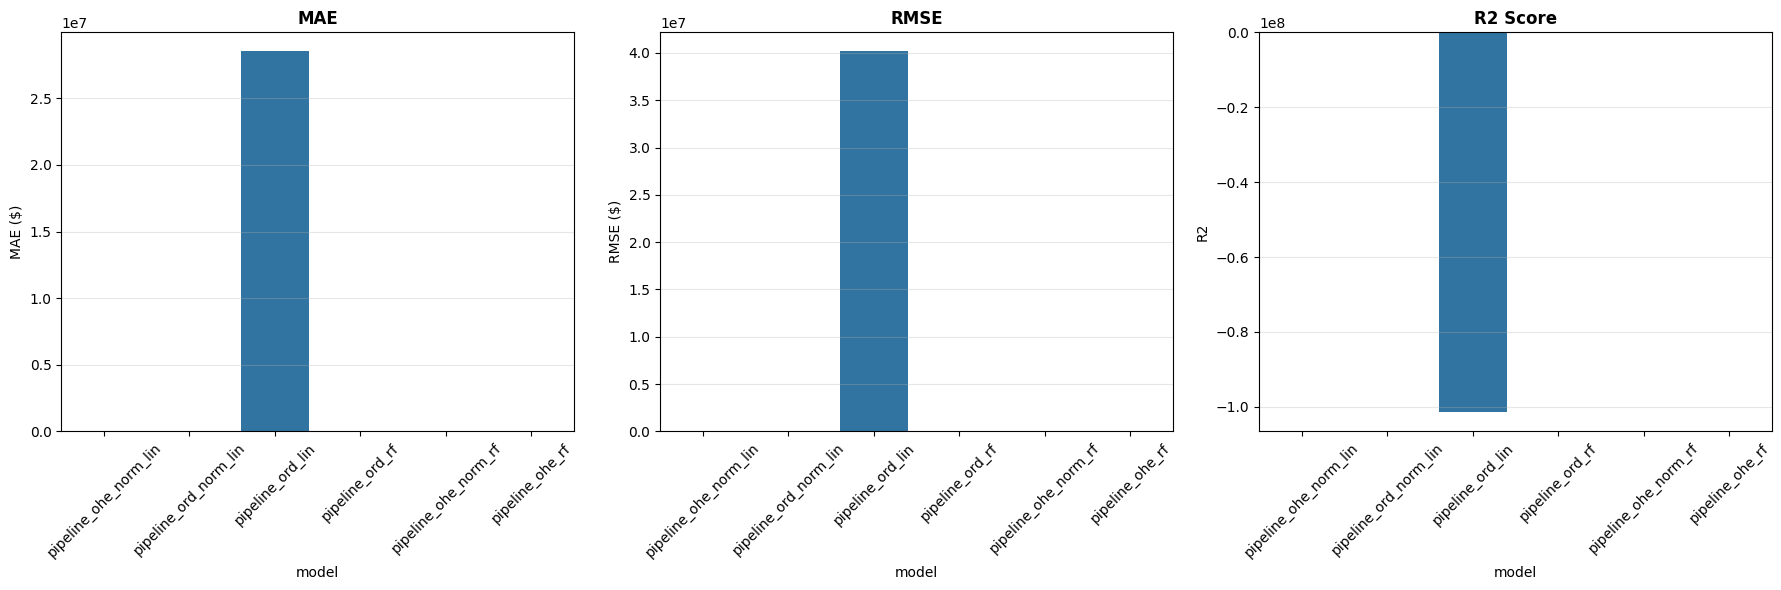

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=results_df, x='model', y='mae', ax=axes[0])
axes[0].set_title('MAE', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('MAE ($)')
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=results_df, x='model', y='rmse', ax=axes[1])
axes[1].set_title('RMSE', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('RMSE ($)')
axes[1].grid(axis='y', alpha=0.3)

sns.barplot(data=results_df, x='model', y='r2', ax=axes[2])
axes[2].set_title('R2 Score', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('R2')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Модель pipeline_ord_lin выдала значения метрик (MAE, RMSE) в миллионы раз больше, чем остальные модели. График автоматически масштабировался по максимальному значению, из-за чего столбцы нормальных моделей стали почти невидимыми.

Я исключили эту модель из данных для графика, отфильтровав строку results_df[results_df['model'] != 'pipeline_ord_lin'], и построила график только для нормально работающих моделей. После этого столбцы стали хорошо видны и сравнимы

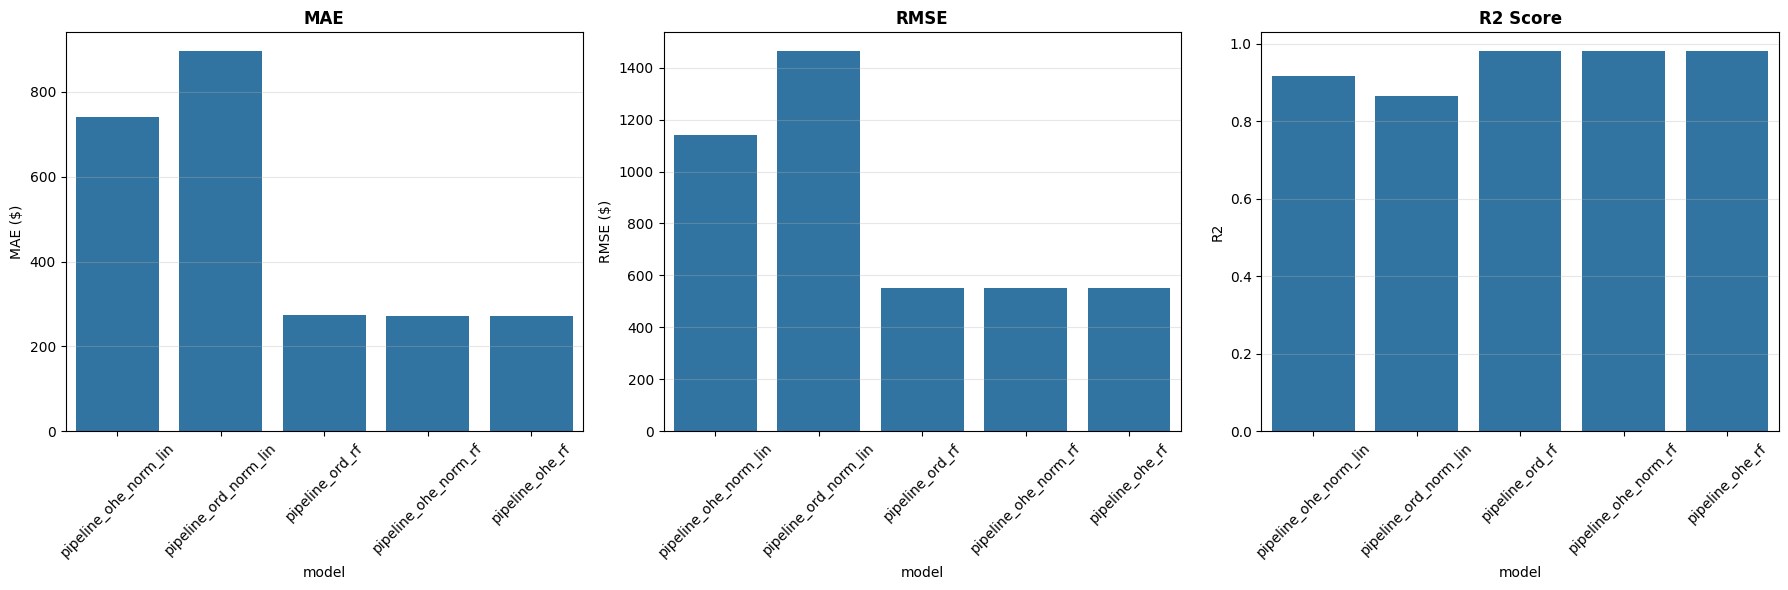

In [20]:
good_models = results_df[results_df['model'] != 'pipeline_ord_lin']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=good_models, x='model', y='mae', ax=axes[0])
axes[0].set_title('MAE', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('MAE ($)')
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=good_models, x='model', y='rmse', ax=axes[1])
axes[1].set_title('RMSE', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('RMSE ($)')
axes[1].grid(axis='y', alpha=0.3)

sns.barplot(data=good_models, x='model', y='r2', ax=axes[2])
axes[2].set_title('R2 Score', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('R2')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Вопросы (1 pt)

1. В чём разница между `One-Hot Encoding` и `Ordinal (Label) Encoding`? Когда какой метод следует использовать?
2. Почему `Ordinal Encoding` опасен для линейной регрессии? Приведите конкретный пример.
3. Что произойдёт, если в тестовых данных появится категория, которой не было в обучающих? Как это обрабатывать?
4. Почему `fit()` вызывается только на `train` данных, а `transform()` — и на `train`, и на `test`? Что будет, если сделать `fit()` на всём датасете?
5. Как на предсказание влияет нормализация?
6. Как интерпретировать полученные метрики?
7. Какую метрику вы бы выбрали как основную для бизнес-задачи предсказания цен на алмазы? Почему?

**ОТВЕТЫ:** 

1. One-Hot Encoding создаёт отдельный бинарный столбец для каждой категории (нет порядка). Ordinal Encoding присваивает категориям числа (0,1,2…). One-Hot подходит для номинальных признаков (цвет, страна), Ordinal – для ординальных (оценка, размер S,M,L). Для линейных моделей лучше One-Hot, для деревьев – можно и Ordinal.

2. Ordinal Encoding опасен для линейной регрессии, потому что он принудительно вводит числовой порядок между категориями, которого может не быть. Например, если закодировать color как red=0, green=1, blue=2, модель решит, что blue в два раза больше green, хотя это не так. Коэффициент при таком признаке будет искажать предсказание. В этой задаче Ordinal без нормализации дал ошибки в миллионы долларов.

3. Если в тесте появилась новая категория, то при One-Hot encoding все бинарные столбцы для неё станут нулями (категория игнорируется). При Ordinal encoding можно заменять новую категорию на -1 (параметр handle_unknown='ignore').

4. fit() вызывается только на тренировочных данных, чтобы вычислить статистики (среднее, дисперсию, категории) без подглядывания в тест. Если сделать fit() на всём датасете, произойдёт утечка данных – параметры нормализации или категории будут учитывать тестовую выборку, и оценка качества станет нечестной.

5. Нормализация приводит признаки к одному масштабу (среднее 0, дисперсия 1). Для линейных моделей она обязательна: без неё градиентный спуск может долго сходиться или расходиться. Для деревьев нормализация не нужна, так как они не используют расстояния.

6. MAE – средняя абсолютная ошибка в долларах. RMSE – корень из средней квадратичной ошибки; если RMSE сильно больше MAE – есть крупные выбросы. R^2 – доля дисперсии, объяснённая моделью (1 – идеал, 0 – как среднее, <0 – хуже среднего). Если конкретно говорить про те модели, которые мы обучали: 
Линейная регрессия без нормализации полностью сломана (ошибки в миллионах, R² отрицательный). Причина: разные масштабы признаков и порядковое кодирование. Линейная регрессия с нормализацией работает корректно. One‑Hot лучше (MAE 746$, R 0.918), чем Ordinal (MAE 910$, R 0.865). Вывод: для линейных моделей обязательна нормализация и предпочтительнее One‑Hot. Случайный лес лучший результат. Все три варианта (Ordinal, One‑Hot с нормализацией и без) показывают почти одинаково высокое качество: MAE  270$, RMSE  550$, R 0.981. Лес не чувствителен ни к масштабу, ни к типу кодирования.

7. Для бизнес-задачи предсказания цен на алмазы я бы выбрала MAE, потому что она интерпретируема в тех же деньгах: «В среднем мы ошибаемся на X долларов». Это понятно заказчику. RMSE тоже важен, если крупные ошибки критичны (например, при продаже дорогих камней). R^2 полезен для сравнения моделей, но бизнесу он менее нагляден.

# Классификация (2 pt)

Для этого задания будем использовать датасет `Telco-Customer-Churn` вот [тут](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) можно почитать описание столбцов. Наша задача — предсказать столбец `Churn`, то есть ушел пользователь, или остался.  

В этом пункте мы будем использовать три модели: `LogisticRegression`, `RandomForestClassifier` и `CatBoostClassifier`. Если хотите, то можете подбирать параметры, но можно сравнивать и с параметрами «из коробки».

## Работа с данными (0,5 pt)

In [21]:
TCC = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv').dropna()
# обработка, чтобы была одинаковая у всех
TCC = TCC.drop('customerID', axis=1)
TCC['Churn'] = (TCC['Churn'] == 'Yes').astype(int)
TCC['TotalCharges'] = pd.to_numeric(TCC['TotalCharges'], errors='coerce')
TCC = TCC.dropna()
print(TCC.shape)
TCC.head(3)

(7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [22]:
TCC.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [23]:
X = TCC.drop('Churn', axis=1)
y = TCC['Churn']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train_raw.shape, X_test_raw.shape)

(5625, 19) (1407, 19)


**ЗАДАНИЕ:**  
Проанализируйте столбцы и подготовьте **пайплайн обучения**. Вы можете как использовать свои реализации методов, так и реализации из библиотеки. ВАЖНО аргументировать, почему вы выбрали такую обработку. **ПОЭКСПЕРЕМЕНТИРУЙТЕ С РАЗНЫМИ ПАЙПЛАЙНАМИ**

In [24]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X_train_raw.select_dtypes(include='object').columns]

# Для логистической регрессии 
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Для ансамблей 
preprocessor_ens = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),   # без масштабирования
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ])

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_ens),
    ('model', RandomForestClassifier(random_state=42))
])

pipeline_cb = Pipeline(steps=[
    ('preprocessor', preprocessor_ens),
    ('model', CatBoostClassifier(verbose=0, random_state=42))
])

C:\Users\pochi\AppData\Local\Temp\ipykernel_55040\2330495213.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = [col for col in X_train_raw.select_dtypes(include='object').columns]


**ОБЪЯСНЕНИЕ:**

Логистическая регрессия требует нормализации числовых признаков (иначе градиентный спуск работает плохо) и OneHot-кодирования категорий (чтобы избежать ложного порядка).

Ансамбли (RandomForest, CatBoost) не чувствительны к масштабу, поэтому числовые признаки оставлены как есть (passthrough). Категориальные признаки закодированы порядково (OrdinalEncoder) – это экономит память и ускоряет обучение, а деревья решений сами определят нужные разбиения. Для неизвестных категорий в тесте установлено unknown_value=-1

## Модели и метрики (1 pt)

Если вы хорошо проанализировали данные, то заметили, что у нас явный **дисбалланс классов** (одного класса сильно меньше, чем другого). Поэтому просто точность для нас не подойдет. 

In [25]:
y_train.value_counts()

Churn
0    4130
1    1495
Name: count, dtype: int64

Почему **`accuracy` бесполезна при дисбалансе**:
Если 73% клиентов не уходят, модель, которая всегда предсказывает "No", получит `accuracy` 73%, но будет полностью бесполезна для бизнеса.

**Confusion Matrix (Матрица ошибок)**  
Все правильные метрики строятся на основе `Confusion Matrix`. Это таблица 2x2, которая показывает, какие ошибки делает модель:
|   | Предсказано 0 | Предсказано 1 |
| :-| :------------ | :------------ |
| **Фактически 0** | `True Negative` | `False Positive` |
| **Фактически 1**  | `False Negative` | `True positive` |

На этом основываются другие метрики для классификации помимо `accuracy`:
* **precision** (`TP / (TP + FP)`) — когда ложные срабатывания дороги,
* **recall** (`TP / (TP + FN)`) — когда пропуск объекта стоит дорого,
* **F1-Score** (`2 * (Prec * Rec) / (Prec + Rec)`) — Баланс между precision и recall.

Подробнее читать [про метрики тут](https://habr.com/ru/companies/ods/articles/328372/).

In [26]:
# ЗАДАНИЕ: реализуйте собственные функции метрик
ArrayLike = Union[np.ndarray, pd.Series, List[float]]

def own_confusion_matrix(y_true: ArrayLike, y_pred: ArrayLike) -> Dict[str, int]:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return {'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}

def own_precision_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    cm = own_confusion_matrix(y_true, y_pred)
    tp = cm['TP']
    fp = cm['FP']
    if tp + fp == 0:
        return 0.0
    return tp / (tp + fp)

def own_recall_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    cm = own_confusion_matrix(y_true, y_pred)
    tp = cm['TP']
    fn = cm['FN']
    if tp + fn == 0:
        return 0.0
    return tp / (tp + fn)

def own_f1_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    prec = own_precision_score(y_true, y_pred)
    rec = own_recall_score(y_true, y_pred)
    if prec + rec == 0:
        return 0.0
    return 2 * (prec * rec) / (prec + rec)

def own_accuracy_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    cm = own_confusion_matrix(y_true, y_pred)
    total = cm['TP'] + cm['TN'] + cm['FP'] + cm['FN']
    if total == 0:
        return 0.0
    return (cm['TP'] + cm['TN']) / total

In [27]:
y_true_test = [1, 1, 0, 0, 0]
y_pred_test = [1, 0, 1, 0, 1]

assert np.isclose(own_precision_score(y_true_test, y_pred_test), precision_score(y_true_test, y_pred_test))
assert np.isclose(own_recall_score(y_true_test, y_pred_test), recall_score(y_true_test, y_pred_test))
assert np.isclose(own_f1_score(y_true_test, y_pred_test), f1_score(y_true_test, y_pred_test))
assert np.isclose(own_accuracy_score(y_true_test, y_pred_test), accuracy_score(y_true_test, y_pred_test))

Теперь **обучим** то, что вы сделали

In [28]:
pipelines = [pipeline_lr, pipeline_rf, pipeline_cb]
pipeline_names = ['Logistic Regression', 'Random Forest', 'CatBoost']
metrics = {}

for pipeline, name in tqdm(zip(pipelines, pipeline_names)):
    pipeline.fit(X_train_raw, y_train)

    y_pred = pipeline.predict(X_test_raw)
    y_prob = pipeline.predict_proba(X_test_raw)[:, 1] # если хотите вероятности, а не классы

    metrics[name] = {}
    metrics[name]['precision'] = own_precision_score(y_test, y_pred)
    metrics[name]['recall'] = own_recall_score(y_test, y_pred)
    metrics[name]['f1-score'] = own_f1_score(y_test, y_pred)
    metrics[name]['accuracy'] = own_accuracy_score(y_test, y_pred)

clear_output()

In [29]:
results_df = pd.DataFrame(metrics).T
results_df.index.name = 'model'
results_df = results_df.reset_index()

results_df['precision'] = results_df['precision'].round(2)
results_df['recall'] = results_df['recall'].round(2)
results_df['f1-score'] = results_df['f1-score'].round(4)
results_df['accuracy'] = results_df['accuracy'].round(2)
results_df

,model,precision,recall,f1-score,accuracy
0,Logistic Regression,0.62,0.52,0.5656,0.79
1,Random Forest,0.64,0.47,0.5370,0.79
2,CatBoost,0.63,0.49,0.5539,0.79


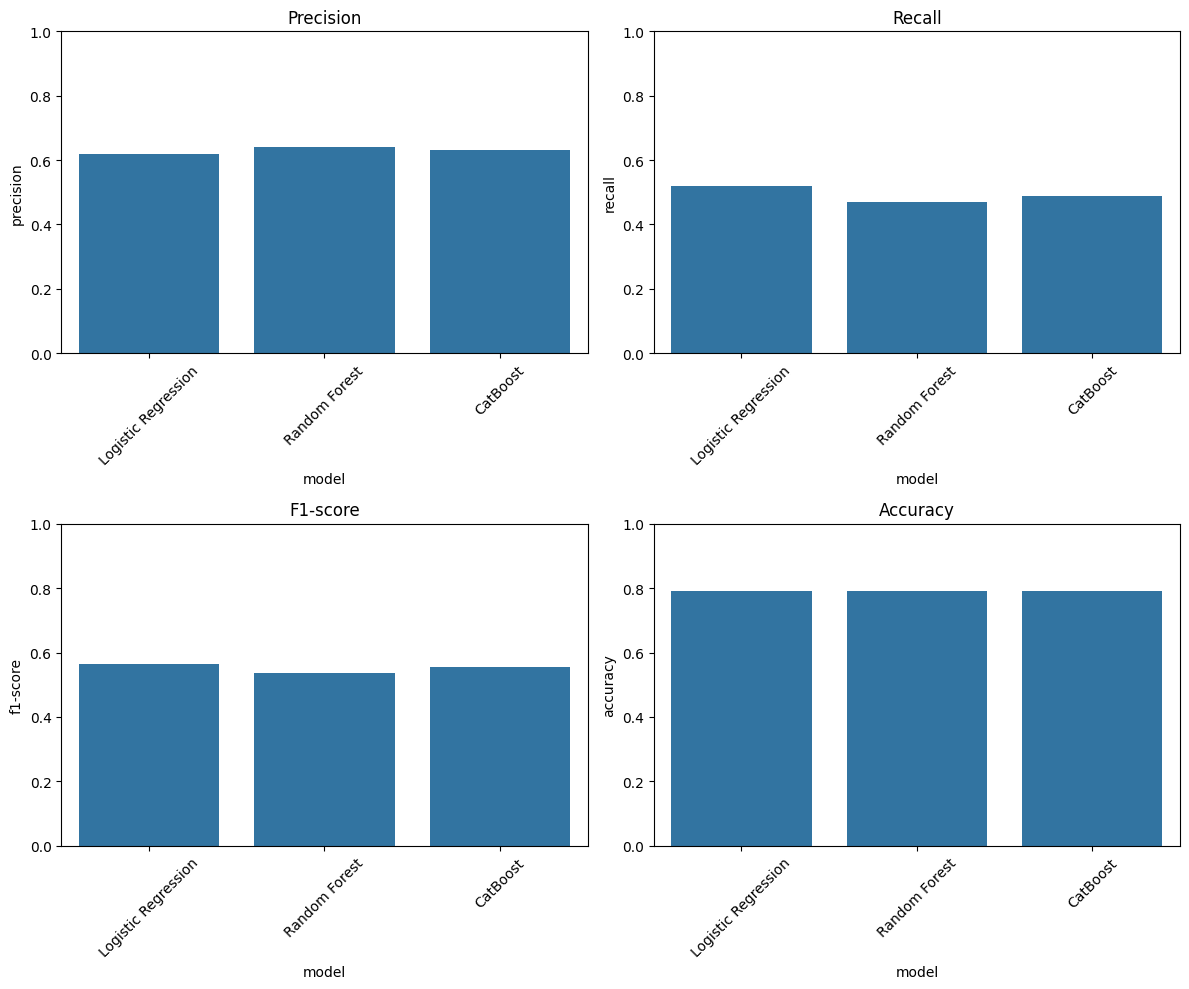

In [30]:
# ЗАДАНИЕ: визуализируйте метрики

# Преобразуем словарь metrics в DataFrame
results_df = pd.DataFrame(metrics).T # метод T меняет строки и столбцы местами, ну то есть транспонирует
results_df.index.name = 'model'
results_df = results_df.reset_index()


results_df['precision'] = results_df['precision'].round(2)
results_df['recall'] = results_df['recall'].round(2)
results_df['f1-score'] = results_df['f1-score'].round(4)
results_df['accuracy'] = results_df['accuracy'].round(2)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.barplot(data=results_df, x='model', y='precision', ax=axes[0,0])
axes[0,0].set_title('Precision')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_ylim(0, 1)

sns.barplot(data=results_df, x='model', y='recall', ax=axes[0,1])
axes[0,1].set_title('Recall')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylim(0, 1)

sns.barplot(data=results_df, x='model', y='f1-score', ax=axes[1,0])
axes[1,0].set_title('F1-score')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylim(0, 1)

sns.barplot(data=results_df, x='model', y='accuracy', ax=axes[1,1])
axes[1,1].set_title('Accuracy')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Вопросы (0,5 pt)

1. Какая обработка данных дает лучший результат?
2. Какая обработка данных подходит для каждой модели лучше?
3. Как интерпретировать полученные метрики?

**ОТВЕТЫ:**

1. Лучший F1 у логистической регрессии (OneHot + нормализация)  
Логистическая регрессия - линейная модель, она требует, чтобы признаки были в одном масштабе (иначе градиентный спуск работает плохо).OrdinalEncoder создал бы порядок, которого нет, что исказило бы коэффициенты. 

2. Для леса и CatBoost я выбрала порядковое кодирование без нормализации.Деревья решений и градиентный бустинг не чувствительны к масштабу признаков и могут работать с порядковыми числами как с метками, не придавая им ложного смысла. OneHot увеличил бы размерность без выигрыша в качестве. 

3.  
- Accuracy 79% неправда: из-за дисбаланса (73% не ушли) модель могла бы предсказывать только “не ушёл” и получить 73% accuracy. Реальные 79% лишь немного лучше, поэтому accuracy не показатель.  
- Precision 62-64%: из всех, кого модель пометила как уходящих, только 63% действительно уходят — это значит, что 37% на самом деле остаются.  
- Recall 47-52%: модель находит лишь половину реальных уходов.
- F1 0,55: низкое значение из-за того, что и precision, и recall невысоки.  



# Кластеризация (2 pt)

**Кластеризация** — это тип задачи обучения без учителя (unsupervised learning), где мы ищем скрытые структуры в данных без заранее известных ответов (y).

**K-Means** — самый популярный алгоритм кластеризации, его и будем использовать.  
Для этого алгоритма очень **важно масштабирование**. K-Means использует **евклидово расстояние** между точками, поэтому если признаки имеют разный масштаб, признак с большим диапазоном полностью определит расстояние.

В этом задании мы используем датасет `Mall_Customers`, вот [тут](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) про него.

## Работа с данными (0,5 pt)

In [31]:
customers = pd.read_csv('Mall_Customers.csv')
customers = customers.drop('CustomerID', axis=1)
print(customers.shape)
customers.head(3)

(200, 4)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6


In [32]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [55]:
X = customers.copy()

Тут не так много категориальных признаков, поэтому анализ и обработка не должны быть сложными

In [56]:
# ЗАДАНИЕ: проанализируйте данные и обработайте их 

# обработка категориального
ct = ColumnTransformer([
    ('gender', OneHotEncoder(drop='first', sparse_output=False), ['Gender'])
], remainder='passthrough').set_output(transform="pandas")

X = ct.fit_transform(X)

# Масштабирование (обязательно для KMeans)
scaler = StandardScaler().set_output(transform="pandas")
X = scaler.fit_transform(X)

X.head()

,gender__Gender_Male,remainder__Age,remainder__Annual Income (k$),remainder__Spending Score (1-100),remainder__Cluster
0,1.128152,-1.424569,-1.738999,-0.434801,0.890263
1,1.128152,-1.281035,-1.738999,1.195704,-0.896218
2,-0.886405,-1.352802,-1.700830,-1.715913,0.890263
3,-0.886405,-1.137502,-1.700830,1.040418,-0.896218
4,-0.886405,-0.563369,-1.662660,-0.395980,0.890263


## Модель и метрики (1 pt)

В качестве метрики будем использовать `silhouette_score`, читать про нее [тут](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html). Также будем смотреть на `inertia_`, эта метрика говорит о сумме квадратов расстояний от каждой точки датасета до центра (центроиды) её кластера.

В этот раз не будем заморачиваться и просто возьмем реализованное.  
Подберем наилучшее `k` и посмотрим, как у нас кластеризуется.

In [57]:
K_range = range(2, 20)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

best_k = K_range[np.argmax(silhouette_scores)]
best_k

12

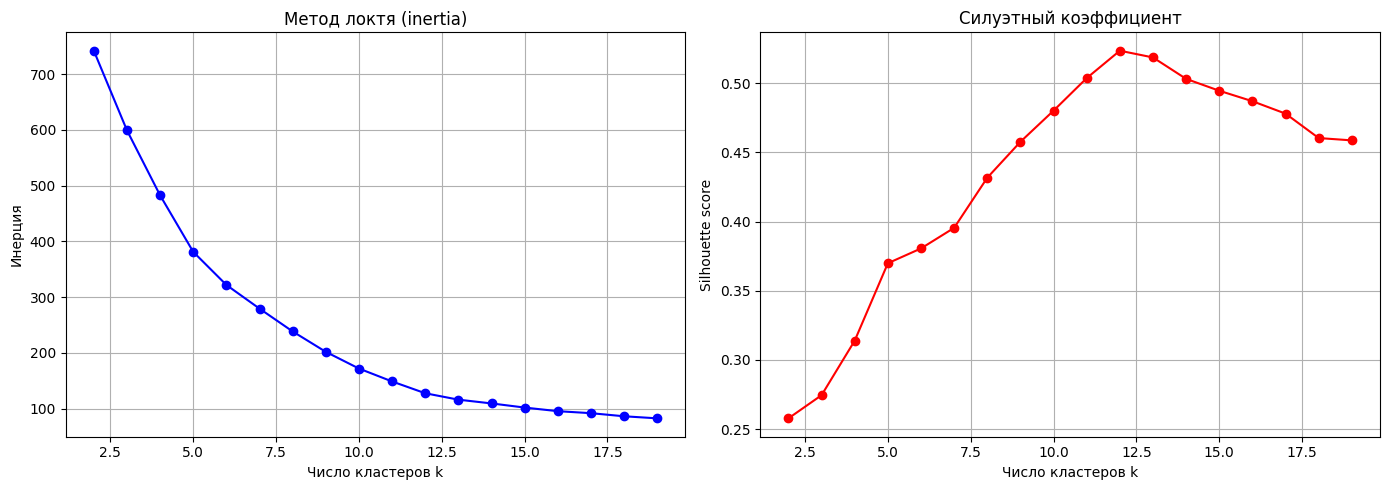

In [58]:
# ЗАДАНИЕ: визуализируйте изменение метрик при изменении k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Метод локтя (inertia)')
axes[0].set_xlabel('Число кластеров k')
axes[0].set_ylabel('Инерция')
axes[0].grid(True)


axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_title('Силуэтный коэффициент')
axes[1].set_xlabel('Число кластеров k')
axes[1].set_ylabel('Silhouette score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [59]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customers['Cluster'] = kmeans_final.fit_predict(X)

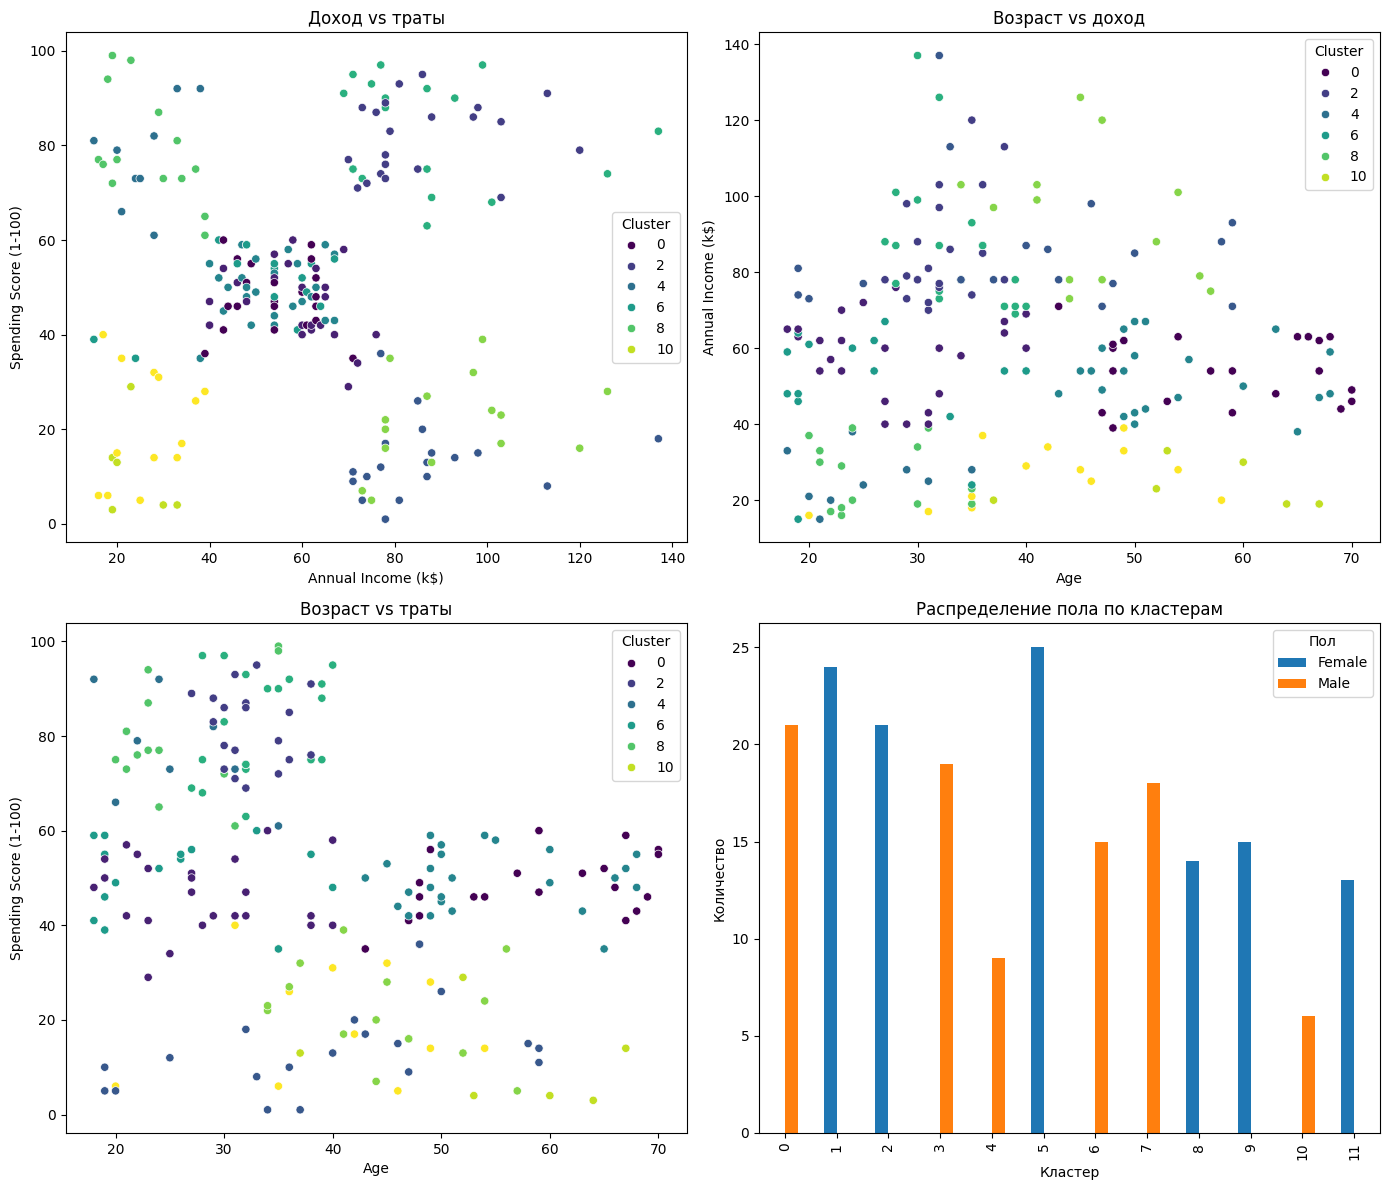

In [60]:
# ЗАДАНИЕ: визуализируйте кластеры
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Доход vs траты
sns.scatterplot(data=customers, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Доход vs траты')

# Возраст vs доход
sns.scatterplot(data=customers, x='Age', y='Annual Income (k$)', hue='Cluster', palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Возраст vs доход')

# Возраст vs траты
sns.scatterplot(data=customers, x='Age', y='Spending Score (1-100)', hue='Cluster', palette='viridis', ax=axes[1,0])
axes[1,0].set_title('Возраст vs траты')

# Распределение пола по кластерам (столбчатая диаграмма)
gender_cluster = pd.crosstab(customers['Cluster'], customers['Gender'])
gender_cluster.plot(kind='bar', ax=axes[1,1], stacked=False)
axes[1,1].set_title('Распределение пола по кластерам')
axes[1,1].set_xlabel('Кластер')
axes[1,1].set_ylabel('Количество')
axes[1,1].legend(title='Пол')

plt.tight_layout()
plt.show()

Повторите обучение для модели **без нормализации** признаков, есть ли разница?

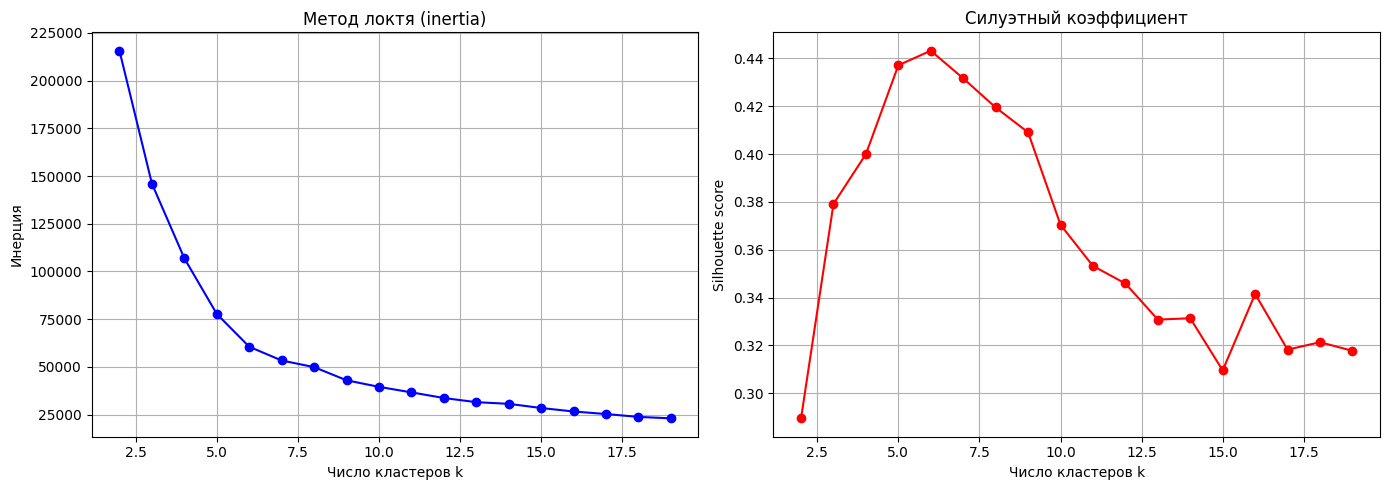
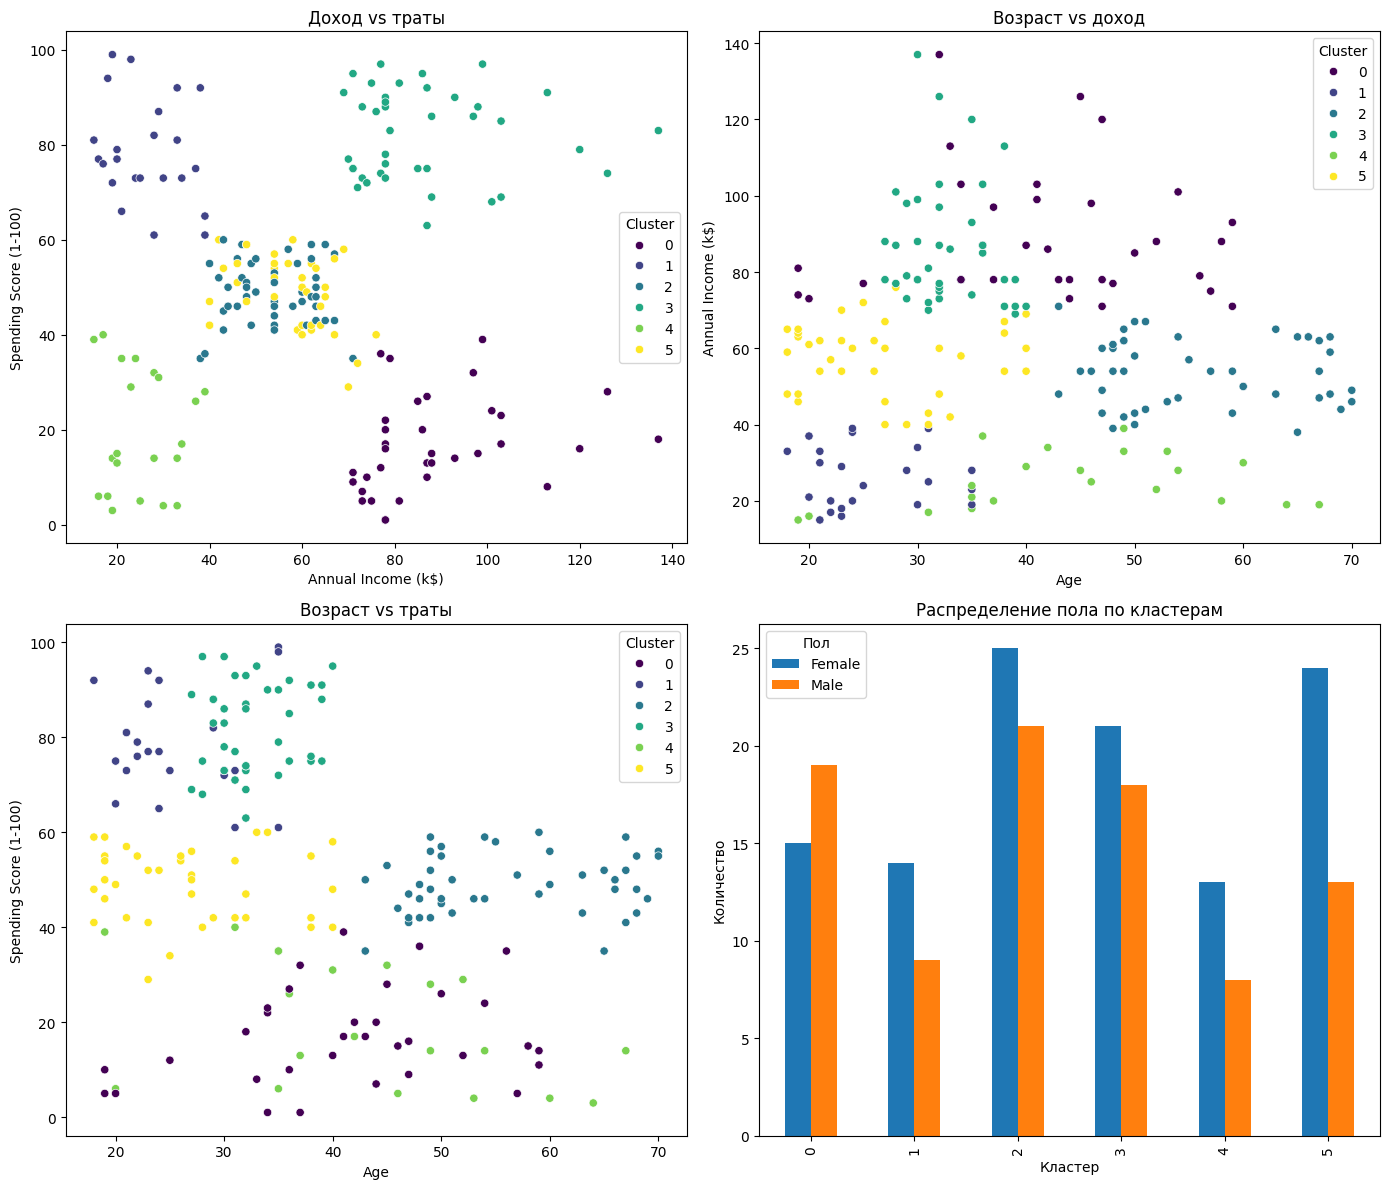

без нормализации выделилось 6 кластеров, разница существенная

In [62]:
# ЗАДАНИЕ: обучите модель на признаках без визуализации

customers_raw = pd.read_csv('Mall_Customers.csv')
customers_raw = customers_raw.drop('CustomerID', axis=1)


ct_no_scaler = ColumnTransformer([
    ('gender', OneHotEncoder(drop='first', sparse_output=False), ['Gender'])
], remainder='passthrough').set_output(transform="pandas")
X_no_scaler = ct_no_scaler.fit_transform(customers_raw)


kmeans_no_scaler = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customers_raw['Cluster'] = kmeans_no_scaler.fit_predict(X_no_scaler)

# Сравниваем метрики
from sklearn.metrics import silhouette_score
inertia_no_scaler = kmeans_no_scaler.inertia_
silhouette_no_scaler = silhouette_score(X_no_scaler, customers_raw['Cluster'])

print(f"С нормализацией: инерция = {kmeans_final.inertia_:.2f}, силуэт = {silhouette_score(X, customers['Cluster']):.4f}")
print(f"Без нормализации: инерция = {inertia_no_scaler:.2f}, силуэт = {silhouette_no_scaler:.4f}")

С нормализацией: инерция = 127.50, силуэт = 0.5236
Без нормализации: инерция = 31698.81, силуэт = 0.3570


**ВЫВОД**:

Нормализация обязательна. Без неё признаки с большими числовыми значениями (например, годовой доход в тысячах) доминируют над признаками с маленькими значениями (возраст, траты). KMeans при этом «видит» только доход, игнорируя остальные характеристики, и кластеризация получается бессмысленной. 

# Итоговый отчет (1 pt)

Напишите итоговый отчет о работе с данными и метриками в формате **советов себе**:
- зафиксируйте, что лучше использовать и как,
- что лучше не использовать и почему,
- какие фишки для упрощения работы вы себе советуете

Отчет должен иметь **структуру** и занимать **не менее 15 строк**.



**1. Что лучше использовать и как**  
- Для регрессии RandomForestRegressor с любым кодированием категорий One‑Hot или Ordinal и без нормализации. Он даёт наилучшее метрики. Лесу все равно на порядок, поэтому можно использовать Ordinal, что оптимальней по времени, по сравнению с One‑Hot.
- Для **классификации** логистическая регрессия с One‑Hot и нормализацией или CatBoost с порядковым кодированием. При дисбалансе классов всегда смотреть на F1, recall, precision, а не на accuracy.  
- Для **кластеризации** KMeans с обязательной нормализацией. Число кластеров выбирать по максимуму силуэта.

**2. Что лучше не использовать и почему**  
- **Ordinal-кодирование без нормализации для линейной регрессии** – приводит к катастрофическим ошибкам из‑за разных масштабов и ложного порядка категорий.  
- **Accuracy при дисбалансе классов** – неинформативна (можно получить высокую accuracy, предсказывая всех «не ушёл», но не найти ни одного реального ухода).  
- **KMeans без нормализации** – признаки с большими значениями (доход) доминируют, кластеризация теряет смысл.  
- **Очистку данных после разделения на train/test** – нарушается соответствие X и y, возникает ошибка размерностей.

**3. Фишки для упрощения работы**    
- Визуализировать метрики.
- Всегда фиксировать `random_state` для воспроизводимости.  

